# Credit Card Fraud Detection - V2

## 1. Introduction

Credit card fraud detection is an important real-world machine learning problem because fraudulent transactions can cause significant financial losses for both customers and financial institutions.

The goal of this project is to build classification models that can distinguish fraudulent transactions from legitimate ones. Since fraud cases are much rarer than normal transactions, this is a highly imbalanced binary classification problem. Because of that, accuracy alone is not a reliable evaluation metric.

In this notebook, I analyze the dataset, perform exploratory data analysis (EDA), preprocess the data, train multiple machine learning models, and evaluate them using metrics that are more suitable for imbalanced classification, such as precision, recall, F1-score, ROC-AUC, and PR-AUC.

The main objective is not only to build models, but also to understand the trade-off between detecting more fraud cases and reducing false alarms from a business perspective.

## 2. Data Loading and Validation

In this section, we load the dataset and inspect its structure.  

Note: When running this notebook in Google Colab, the dataset file may need to be uploaded manually unless a persistent storage path is used.

In [61]:
from google.colab import files
uploaded = files.upload()

Saving creditcardfraud.zip to creditcardfraud (2).zip


In [62]:
!unzip -o /content/creditcardfraud.zip -d /content/

Archive:  /content/creditcardfraud.zip
  inflating: /content/creditcard.csv  


In [63]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

SEED = 42
TARGET = "Class"
TEST_SIZE = 0.2

print("Libraries imported successfully.")

Libraries imported successfully.


In [64]:
print(os.listdir("/content"))
df = pd.read_csv("/content/creditcard.csv")
df.head()

['.config', 'creditcard.csv', 'creditcardfraud (1).zip', 'creditcardfraud.zip', 'creditcardfraud (2).zip', 'sample_data']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [65]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nTarget distribution:")
print(df[TARGET].value_counts())

print("\nTarget distribution (%):")
print(df[TARGET].value_counts(normalize=True) * 100)

print("\nTotal missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Target distribution (%):
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

Total missing values: 0
Duplicate rows: 1081


## 3. Dataset Overview

This dataset contains anonymized credit card transactions labeled as fraudulent or legitimate.

The target variable is `Class`:
- `0` = legitimate transaction
- `1` = fraudulent transaction

Since fraudulent transactions are very rare, this is a highly imbalanced classification problem.  
This imbalance makes metrics such as precision, recall, F1-score, PR-AUC, and ROC-AUC more informative than accuracy alone.

In [66]:
print("Dataset shape:", df.shape)

Dataset shape: (284807, 31)


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


### 3.1 Data Quality Check
Before moving into exploratory analysis, we check the dataset for missing values and duplicate rows.

In [69]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values: 0
Duplicate rows: 1081


#### Observations

The dataset contains no missing values, so no imputation is required at this stage.  
However, there are 1,081 duplicate rows in the dataset.  
Because removing duplicates at this point would change the downstream pipeline and all reported model outputs, they are retained in this version and noted as a potential improvement for future work.

## 4. Exploratory Data Analysis

### 4.1 Class Distribution

In this section, we examine the distribution of fraudulent and non-fraudulent transactions.  


In [70]:
print(df["Class"].value_counts())

print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


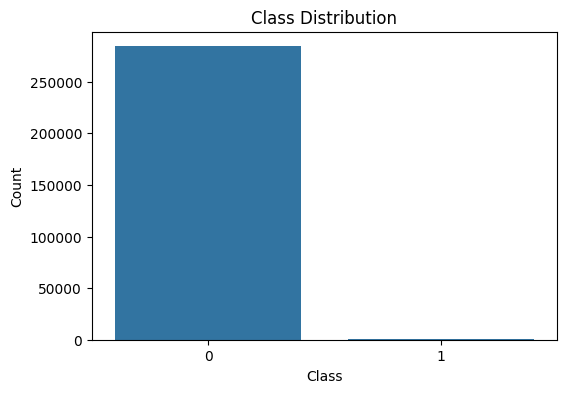

In [71]:
plt.figure(figsize=(6,4))
sns.countplot(x=TARGET, data=df)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is highly imbalanced. Fraudulent transactions represent only a very small fraction of all observations, which means accuracy alone would be misleading for model evaluation.

### 4.2 Transaction Amount Distribution

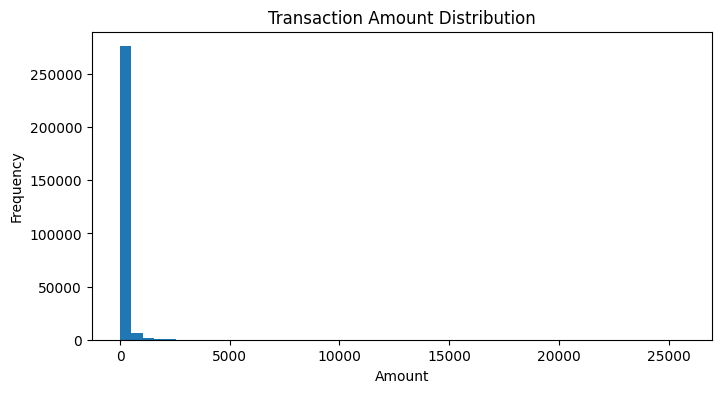

In [72]:
plt.figure(figsize=(8,4))
plt.hist(df["Amount"], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

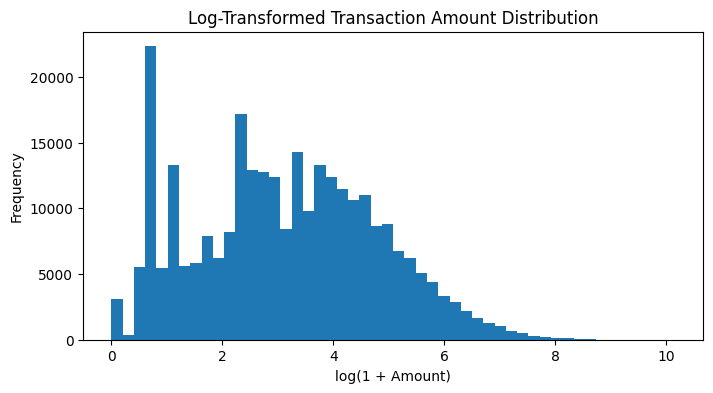

In [73]:
plt.figure(figsize=(8,4))
plt.hist(np.log1p(df["Amount"]), bins=50)
plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log(1 + Amount)")
plt.ylabel("Frequency")
plt.show()

Transaction amounts are highly right-skewed. Most transactions are concentrated at lower values, while a small number of transactions have very large amounts. The log-transformed distribution provides a clearer view of the overall pattern and makes the variable easier to interpret.

### 4.3 Transaction Time Distribution

In this section, we examine the distribution of the `Time` variable to better understand how transactions are spread across the dataset timeline.

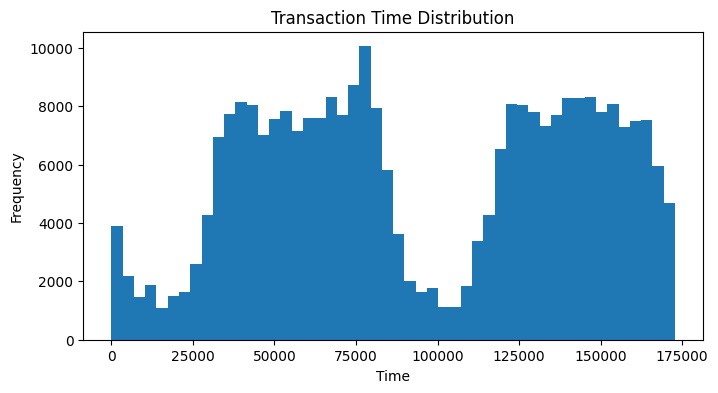

In [74]:
plt.figure(figsize=(8,4))
plt.hist(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

The `Time` variable shows that transactions are not evenly distributed across the dataset timeline. There are clear fluctuations in transaction frequency over time. Although the raw `Time` feature may not be directly interpretable on its own, it may still become useful after feature engineering.

### 4.4 Transaction Amount by Class
In this section, I compare the transaction amount distributions for normal and fraudulent transactions to see whether fraud cases tend to occur in different amount ranges.

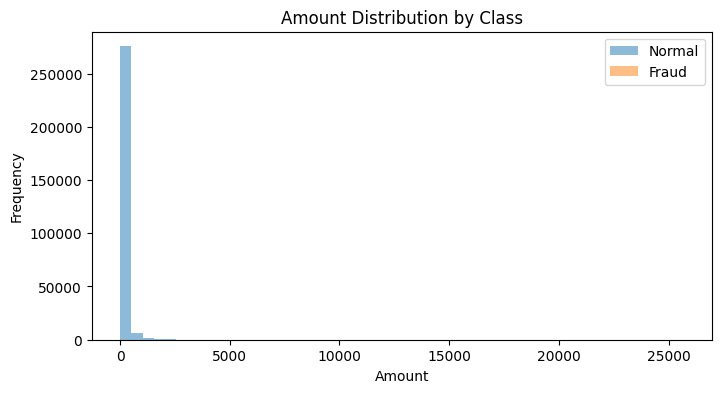

In [75]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

plt.figure(figsize=(8,4))
plt.hist(normal["Amount"], bins=50, alpha=0.5, label="Normal")
plt.hist(fraud["Amount"], bins=50, alpha=0.5, label="Fraud")
plt.title("Amount Distribution by Class")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.legend()
plt.show()

The amount distribution is highly right-skewed, meaning that most transactions occur at relatively low amounts, while a small number of transactions have very large values.

However, because the dataset is extremely imbalanced, normal transactions dominate the plot and fraudulent transactions are barely visible. As a result, this chart is useful for understanding the overall shape of transaction amounts, but it is not sufficient for a clear class-based comparison on its own.

### 4.5 Hour Distribution

In this section, we convert transaction time from seconds into hourly values to better understand how transactions are distributed across the day.

In [76]:
df["Hour"] = (df["Time"] // 3600) % 24

print(df["Hour"].describe())
print("\nUnique hour values:", sorted(df["Hour"].unique()))

count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

Unique hour values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(23.0)]


#### Observations

The `Time` feature was converted into an hourly variable (`Hour`) ranging from 0 to 23.  
This makes the temporal pattern of transactions easier to interpret compared to raw seconds.  
The distribution suggests that transactions are spread across the full day, with a concentration around midday and afternoon hours.

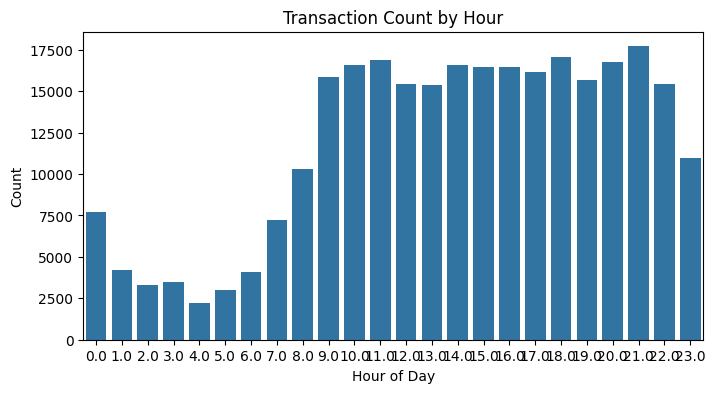

In [77]:
plt.figure(figsize=(8,4))
sns.countplot(x="Hour", data=df)
plt.title("Transaction Count by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")
plt.show()

#### Observations

Transaction activity is relatively low during the early morning hours and starts to increase after around 08:00–09:00.  
The highest transaction volume appears during daytime and evening hours, suggesting a clear daily usage pattern.  
This indicates that converting `Time` into `Hour` provides a more interpretable temporal feature for analysis.

### 4.6 Fraud vs Normal Transactions by Hour

In this section, we examine whether the proportion of fraudulent transactions changes across hours of the day. Since raw transaction counts are highly imbalanced, fraud rate provides a more interpretable comparison.

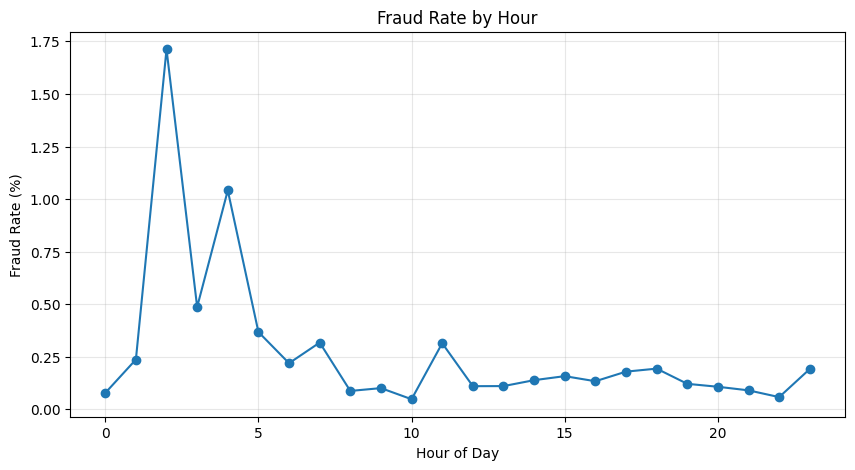

In [78]:
hourly_fraud_rate = df.groupby("Hour")["Class"].mean() * 100

plt.figure(figsize=(10,5))
hourly_fraud_rate.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

#### Observations

The fraud rate is not constant throughout the day and shows noticeable variation across hours.  
A visible spike appears during the early morning hours, especially around 02:00–04:00.  
For most daytime and evening hours, the fraud rate remains relatively lower and more stable.  
This suggests that transaction timing may contain useful signal, although early-hour peaks should be interpreted carefully because they may be based on fewer total transactions.

### EDA Summary

The exploratory analysis confirms that the dataset is highly imbalanced, with fraudulent transactions representing only a very small fraction of all observations.  
Transaction amount is strongly right-skewed, making log transformation useful for interpretation.  
Time-based exploration also suggests that transaction behavior changes across the day, and the fraud rate is not evenly distributed by hour.  
These findings motivate the use of careful preprocessing, imbalance-aware evaluation metrics, and threshold-based decision analysis in the modeling stage.

## 5. Data Preprocessing
In this section, we prepare the dataset for modeling by defining features and target, creating train-test splits, and applying preprocessing steps in a way that avoids data leakage.

### 5.1 Define Features and Target

We separate the input features (`X`) from the target variable (`y`) before splitting the data.  
Since `Hour` was created earlier for EDA purposes, it is excluded here and will be reintroduced later during feature engineering.

In [79]:
X = df.drop(["Class", "Hour"], axis=1)
y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (284807, 30)
y shape: (284807,)

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64


### 5.2 Train-Test Split
To evaluate the model on unseen data, we split the dataset into training and test sets using stratification to preserve the class distribution.

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train distribution:\n", y_train.value_counts())
print("\ny_test distribution:\n", y_test.value_counts())

X_train shape: (227845, 30)
X_test shape: (56962, 30)
y_train distribution:
 Class
0    227451
1       394
Name: count, dtype: int64

y_test distribution:
 Class
0    56864
1       98
Name: count, dtype: int64


### 5.3 Feature Engineering
We create an additional feature from transaction time to make temporal patterns more interpretable for the models.

In [81]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["Hour"] = (X_train["Time"] // 3600) % 24
X_test["Hour"] = (X_test["Time"] // 3600) % 24

print("X_train shape after feature engineering:", X_train.shape)
print("X_test shape after feature engineering:", X_test.shape)
print("\nNew feature added: Hour")

X_train shape after feature engineering: (227845, 31)
X_test shape after feature engineering: (56962, 31)

New feature added: Hour


### 5.4 Feature Scaling
Since `Time`, `Amount`, and the engineered `Hour` feature are not on the same scale as the PCA-transformed variables, we apply standardization before training the baseline model.

To avoid data leakage, the scaler is fitted only on the training data and then applied to the test data.

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scale_cols = ["Time", "Amount", "Hour"]

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Scaled columns:", scale_cols)
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Scaled columns: ['Time', 'Amount', 'Hour']
X_train_scaled shape: (227845, 31)
X_test_scaled shape: (56962, 31)


### 5.5 Preprocessing Check

Before moving to modeling, we verify that the scaled dataset is ready and that the selected columns were transformed correctly.

In [83]:
print(X_train_scaled[["Time", "Amount", "Hour"]].describe().T)

           count          mean       std       min       25%       50%  \
Time    227845.0 -1.407707e-16  1.000002 -1.998073 -0.856150 -0.212265   
Amount  227845.0 -2.020811e-17  1.000002 -0.351689 -0.329194 -0.263943   
Hour    227845.0  9.258932e-17  1.000002 -2.409653 -0.694601  0.162926   

             75%         max  
Time    0.936629    1.640549  
Amount -0.042622  102.117000  
Hour    0.848947    1.534968  


#### Observations

The selected columns were successfully standardized on the training set.  
Their means are close to 0 and standard deviations are close to 1, confirming that scaling was applied correctly.  
At this point, the dataset is ready for baseline modeling.

## 6. Baseline Model: Logistic Regression
In this section, we train a Logistic Regression model as a baseline and evaluate its performance on the test set using imbalance-aware classification metrics.

### 6.1 Train the Baseline Model
Logistic Regression is used as a strong baseline for imbalanced binary classification because it is simple, interpretable, and efficient.

In [84]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### 6.2 Test Set Evaluation
We evaluate the baseline model on the test set using confusion matrix, classification report, ROC-AUC, and PR-AUC.

In [85]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("PR-AUC:", average_precision_score(y_test, y_proba_lr))

Confusion Matrix:

[[55362  1502]
 [    9    89]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9998    0.9736    0.9865     56864
           1     0.0559    0.9082    0.1054        98

    accuracy                         0.9735     56962
   macro avg     0.5279    0.9409    0.5460     56962
weighted avg     0.9982    0.9735    0.9850     56962

ROC-AUC: 0.9737475128627702
PR-AUC: 0.7221687533968105


#### Observations

The baseline Logistic Regression model achieves high recall, meaning that it identifies most fraudulent transactions.  
However, its precision is very low, indicating that many legitimate transactions are incorrectly classified as fraud.  
While ROC-AUC and PR-AUC indicate good discrimination ability, the default classification threshold does not provide a balanced precision-recall trade-off.

### 6.3 Baseline Metrics Table

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

lr_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)],
    "Precision": [precision_score(y_test, y_pred_lr)],
    "Recall": [recall_score(y_test, y_pred_lr)],
    "F1-Score": [f1_score(y_test, y_pred_lr)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_lr)],
    "PR-AUC": [average_precision_score(y_test, y_proba_lr)]
})

lr_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9735,0.0559,0.9082,0.1054,0.9737,0.7222


#### Summary

This baseline result will be used as the main reference point when evaluating more advanced models.

## 7. Tree-Based Model: Random Forest
In this section, we train a Random Forest classifier to compare a non-linear tree-based approach against the Logistic Regression baseline.

### 7.1 Train the Random Forest Model
Random Forest can capture non-linear relationships and interactions between features, which may improve fraud detection performance compared to a linear baseline.

In [87]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


### 7.2 Test Set Evaluation
We evaluate the Random Forest model on the test set using the same metrics as the baseline model for a fair comparison.

In [88]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("PR-AUC:", average_precision_score(y_test, y_proba_rf))

Confusion Matrix:

[[56861     3]
 [   24    74]]

Classification Report:

              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     56864
           1     0.9610    0.7551    0.8457        98

    accuracy                         0.9995     56962
   macro avg     0.9803    0.8775    0.9227     56962
weighted avg     0.9995    0.9995    0.9995     56962

ROC-AUC: 0.9622294296165287
PR-AUC: 0.8668740190725254


#### Observations

The Random Forest model achieves much higher precision than Logistic Regression, which means that it produces far fewer false positive fraud alerts.  
Its recall is lower than the baseline model, indicating that some fraudulent transactions are still missed.  
Overall, the model provides a much stronger precision-recall balance and substantially improves the fraud-class F1-score.  
This makes Random Forest a strong candidate for further evaluation and threshold-based tuning.

### 7.3 Random Forest Metrics Summary
The key Random Forest results are summarized below for easier comparison with the baseline model.

In [89]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

rf_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred_rf)],
    "Precision": [precision_score(y_test, y_pred_rf)],
    "Recall": [recall_score(y_test, y_pred_rf)],
    "F1-Score": [f1_score(y_test, y_pred_rf)],
    "ROC-AUC": [roc_auc_score(y_test, y_proba_rf)],
    "PR-AUC": [average_precision_score(y_test, y_proba_rf)]
})

rf_results.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Random Forest,0.9995,0.961,0.7551,0.8457,0.9622,0.8669


#### Summary

Compared with the Logistic Regression baseline, Random Forest provides a much stronger precision-recall balance and a substantially higher F1-score for the fraud class.

## 8. Cross-Validation and Threshold Tuning
In this section, we evaluate model stability with cross-validation and then examine how changing the decision threshold affects fraud detection performance.


### 8.1 Cross-Validation for Logistic Regression
To reduce dependence on a single train-test split, we evaluate the Logistic Regression baseline with stratified cross-validation using PR-AUC as the scoring metric.


In [90]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_pr_auc = cross_val_score(
    lr_pipeline,
    X,
    y,
    cv=cv,
    scoring="average_precision",
    n_jobs=-1
)

print("Logistic Regression CV PR-AUC scores:", lr_cv_pr_auc)
print("Mean CV PR-AUC:", lr_cv_pr_auc.mean())
print("Std CV PR-AUC:", lr_cv_pr_auc.std())

Logistic Regression CV PR-AUC scores: [0.71524433 0.73161812 0.74919617 0.77898116 0.73512743]
Mean CV PR-AUC: 0.7420334430563458
Std CV PR-AUC: 0.021402181620831254


#### Observations

The cross-validation results show that Logistic Regression achieves relatively consistent PR-AUC performance across different folds.  
The mean PR-AUC is around 0.74, with low variation between folds, suggesting that the baseline model is reasonably stable.  
This supports the earlier test-set result and indicates that the model captures meaningful fraud-related patterns, even though its default threshold still leads to poor precision.

### 8.2 Precision-Recall Curve and Threshold Tuning

Since fraud detection is a highly imbalanced classification problem, the default decision threshold of 0.5 may not produce the most suitable precision-recall balance.  
To better understand this trade-off, we examine the precision-recall curve and evaluate alternative threshold values.

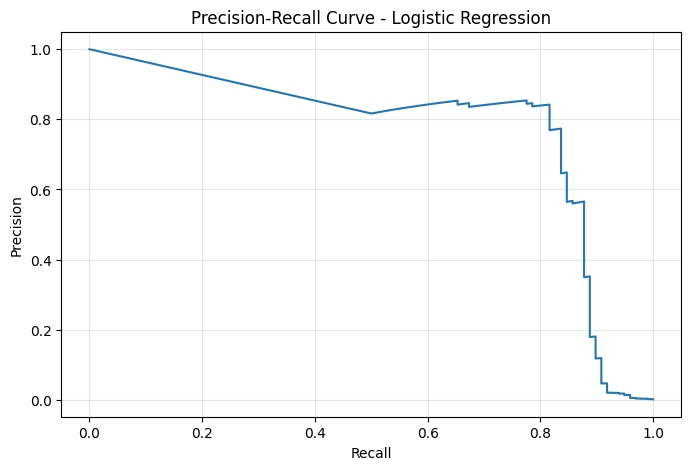

In [91]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_lr)

plt.figure(figsize=(8,5))
plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True, alpha=0.3)
plt.show()

#### Observations

The precision-recall curve shows that Logistic Regression can maintain relatively high precision at lower to moderate recall levels.  
However, as recall increases toward its highest values, precision drops sharply.  
This confirms that the default threshold is not necessarily the best operating point and that threshold tuning may produce a more practical precision-recall balance.

In [92]:
threshold_candidates = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for threshold in threshold_candidates:
    y_pred_thresh = (y_proba_lr >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.1,0.0087,0.9592,0.0172
1,0.2,0.0169,0.9490,0.0331
2,0.3,0.0270,0.9184,0.0524
3,0.4,0.0403,0.9184,0.0772
4,0.5,0.0559,0.9082,0.1054


#### Observations

The threshold comparison shows that very low threshold values lead to extremely poor precision, even though recall remains high.  
As the threshold increases, precision improves gradually while recall decreases only slightly.  
However, even at the default threshold of 0.5, precision is still very low, indicating that Logistic Regression generates too many false positive alerts.  
This suggests that threshold tuning alone may provide limited improvement, and model choice remains a critical factor.

In [93]:
threshold_candidates_high = [0.6, 0.7, 0.8, 0.9]

threshold_results_high = []

for threshold in threshold_candidates_high:
    y_pred_thresh = (y_proba_lr >= threshold).astype(int)

    threshold_results_high.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "Recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred_thresh, zero_division=0)
    })

threshold_df_high = pd.DataFrame(threshold_results_high)
threshold_df_high.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.6,0.0811,0.9082,0.1490
1,0.7,0.1101,0.9082,0.1965
2,0.8,0.1457,0.8980,0.2507
3,0.9,0.2037,0.8878,0.3314


#### Observations

Higher threshold values produce a much better precision-recall balance for Logistic Regression.  
In particular, thresholds around 0.8 to 0.9 improve precision substantially while keeping recall relatively high.  
Among the tested values, 0.9 provides the strongest F1-score and a much more practical trade-off than the default threshold of 0.5.

### 8.3 Before/After Threshold Comparison
To understand the practical effect of threshold tuning, we compare the default threshold of 0.5 with the selected threshold of 0.9.


In [94]:
y_pred_lr_09 = (y_proba_lr >= 0.9).astype(int)

lr_threshold_comparison = pd.DataFrame({
    "Setting": ["Default (0.5)", "Tuned (0.9)"],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_lr_09, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr_09, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr_09, zero_division=0)
    ]
})

lr_threshold_comparison.round(4)

,Setting,Precision,Recall,F1-Score
0,Default (0.5),0.0559,0.9082,0.1054
1,Tuned (0.9),0.2037,0.8878,0.3314


#### Observations

Threshold tuning significantly improves the practical performance of Logistic Regression.  
When the threshold is increased from 0.5 to 0.9, precision rises substantially while recall decreases only slightly.  
As a result, the fraud-class F1-score improves markedly, showing that the default threshold was not the most effective operating point for this problem.

## 9. Model Comparison
In this section, we compare the final performance of the baseline Logistic Regression model, the tuned Logistic Regression version, and the Random Forest model.

### 9.1 Final Results Table
The table below summarizes the final test-set performance of all evaluated model settings.

In [95]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression (0.5)", "Logistic Regression (0.9)", "Random Forest"],
    "Precision": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_lr_09, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr_09, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr_09, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_lr),
        average_precision_score(y_test, y_proba_rf)
    ]
})

final_comparison.round(4)

,Model,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
0,Logistic Regression (0.5),0.0559,0.9082,0.1054,0.9737,0.7222
1,Logistic Regression (0.9),0.2037,0.8878,0.3314,0.9737,0.7222
2,Random Forest,0.9610,0.7551,0.8457,0.9622,0.8669


#### Observations

The final comparison shows clear differences between the evaluated model settings.  
Threshold tuning improves Logistic Regression substantially by increasing precision and F1-score, while keeping recall relatively high.  
However, Random Forest still provides the strongest overall balance, achieving very high precision and the best fraud-class F1-score, although its recall is lower than Logistic Regression.  
This highlights an important trade-off in fraud detection: catching more fraud cases versus reducing false positive alerts.

## 10. Business Interpretation

In this section, we interpret the model results from an operational perspective by considering the trade-off between missed fraud cases and false positive alerts.

### 10.1 Missed Fraud vs False Alarms

In fraud detection, model performance should not be judged only by statistical metrics.  
A model with high recall may still be costly if it generates too many false alarms, while a model with high precision may still be risky if it misses too many fraud cases.

In [96]:
business_df = pd.DataFrame({
    "Model": ["Logistic Regression (0.5)", "Logistic Regression (0.9)", "Random Forest"],
    "False Positives": [
        confusion_matrix(y_test, y_pred_lr)[0, 1],
        confusion_matrix(y_test, y_pred_lr_09)[0, 1],
        confusion_matrix(y_test, y_pred_rf)[0, 1]
    ],
    "False Negatives": [
        confusion_matrix(y_test, y_pred_lr)[1, 0],
        confusion_matrix(y_test, y_pred_lr_09)[1, 0],
        confusion_matrix(y_test, y_pred_rf)[1, 0]
    ],
    "True Positives": [
        confusion_matrix(y_test, y_pred_lr)[1, 1],
        confusion_matrix(y_test, y_pred_lr_09)[1, 1],
        confusion_matrix(y_test, y_pred_rf)[1, 1]
    ]
})

business_df

,Model,False Positives,False Negatives,True Positives
0,Logistic Regression (0.5),1502,9,89
1,Logistic Regression (0.9),340,11,87
2,Random Forest,3,24,74


#### Observations

The business trade-off becomes much clearer when false positives and false negatives are compared directly.  
The default Logistic Regression model misses very few fraud cases, but it generates a very large number of false alarms.  
After threshold tuning, Logistic Regression reduces false positives substantially while keeping a similar number of detected fraud cases.  
Random Forest produces by far the fewest false alarms, but it misses more fraudulent transactions than Logistic Regression.  
This means the preferred model depends on business priorities: minimizing missed fraud or minimizing unnecessary alerts.

## 11. Conclusion and Next Steps
This project revisited the credit card fraud detection problem with a more structured and professional workflow.  
The analysis began with data validation and exploratory analysis, which confirmed the severe class imbalance and revealed useful patterns in transaction amount and transaction time.  
Feature engineering and preprocessing were then applied carefully to avoid data leakage and prepare the data for modeling.

The baseline Logistic Regression model achieved high recall but produced too many false positive alerts under the default threshold.  
Cross-validation showed that its PR-AUC performance was reasonably stable, and threshold tuning improved its precision-recall balance substantially.  
However, the Random Forest model delivered the strongest overall fraud-class F1-score and the best precision, making it the most balanced option among the evaluated approaches.

Overall, this project highlights an important practical lesson in fraud detection: the best model depends not only on statistical performance, but also on business priorities.  
If the main goal is to minimize missed fraud cases, a high-recall setting may be preferred.  
If the goal is to reduce unnecessary investigations and false alarms, a more precise model may be more suitable.

### Limitations
- The dataset is highly imbalanced, which makes evaluation sensitive to a small number of fraud cases.
- Only a limited set of models was tested.
- The anonymized PCA-transformed features reduce interpretability.
- Threshold tuning was demonstrated on the test set, so a more rigorous validation strategy could further strengthen the analysis.

### Next Steps
- Add cross-validation for Random Forest and compare stability across models.
- Test additional imbalance-handling methods such as SMOTE or class-balanced resampling.
- Perform hyperparameter tuning for Random Forest and Logistic Regression.
- Add feature importance analysis for the tree-based model.
- Evaluate threshold selection on a validation set instead of the test set.
- Improve the GitHub README with project workflow, EDA visuals, and metric snapshots.